# Drawing and InteractionCovers drawing shapes and text, then building interactive mouse tools, annotations, and trackbars.

## Import libraries

In [1]:
# import Open CV library
import cv2

import matplotlib.pyplot as plt
import numpy as np

## Draw line
<code>cv2.line(img, starting point, ending point, color, thickness)</code>
 - Example : </code>cv2.line(img, (50,50), (200,50), (0,255,0), 3)</code>

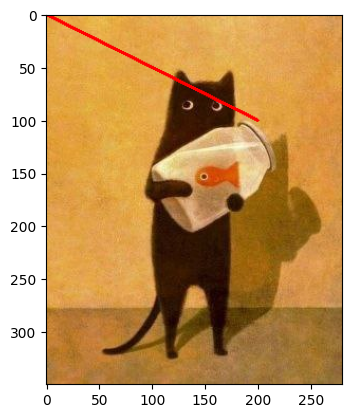

In [10]:
im = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)
# Line
cv2.line(im,(0,0),(200,100),(255,0,0),2)
plt.imshow(im)

## Draw rectangle
<code>cv2.rectangle(img, starting vertex, opposite vertex, color, thickness)</code><br>
<code>thickness = -1</code> fills the shape.
- Example : <code>cv2.rectangle(img, (60,60), (180,180), (255,0,0), 2)</code>

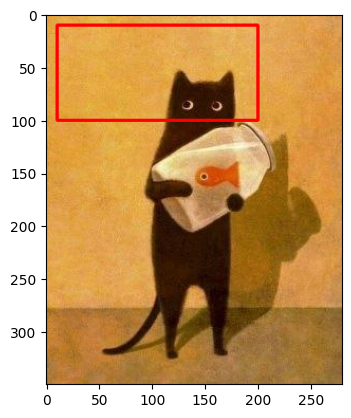

In [12]:
im = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)
# Rectangle
cv2.rectangle(im,(10,10),(200,100),(255,0,0),2)
plt.imshow(im)

## Draw circle
<code>cv2.circle(img, center, radius, color, thickness)</code><br>
<code>thickness = -1</code> fills the shape.
- Example : <code>cv2.circle(img, (120,120), 50, (0,0,255), -1)</code>

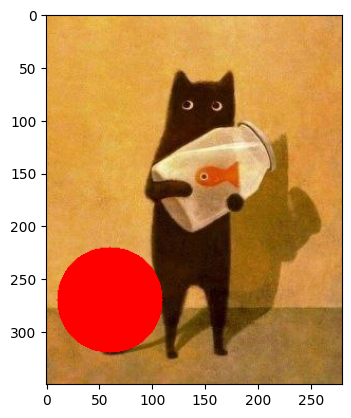

In [24]:
im = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)
# Circle
cv2.circle(im,(60,270),50,(255, 0, 0),-1)
plt.imshow(im)

## Draw ellipse
<code>cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color, thickness)</code><br>
<code>thickness = -1</code> fills the shape.
- Example : <code>cv2.ellipse(img, (150,150), (80,40), 30, 0, 360, (255,255,0), 2)</code>

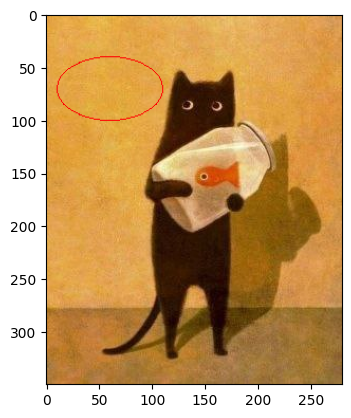

In [37]:
im = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)
# Ellipse
cv2.ellipse(im,(60,70),(50,30),0,0,360,(255, 0, 0),1)
plt.imshow(im)

## Draw polyline
<code>cv2.polylines(img, [pts], isClosed, color, thickness)</code><br>
<code>pts</code> → array of points [[x1,y1],[x2,y2],...].<br>
<code>isClosed = True</code> to connect last point to first (polygon), otherwise <code>False</code>.
- Example :<br> <code>pts = np.array([[50,50],[200,50],[170,150],[80,150]], np.int32)</code><br>
                  <code>pts = pts.reshape((-1,1,2))</code> OpenCV’s cv2.polylines() expects the points in a very specific shape<br> 
                  <code>cv2.polylines(img, [pts], True, (0,255,255), 2)</code><br>

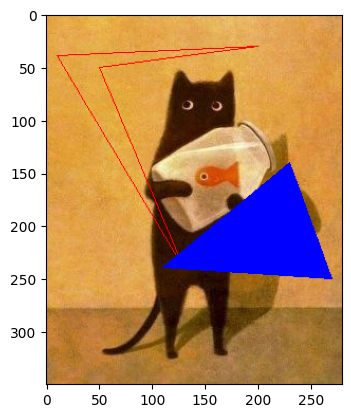

In [57]:
im = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)
# Red Polylines
pts = np.array([[50,50],[130,240],[10,39],[200,30]], np.int32)
pts = pts.reshape((-1,1,2))
cv2.polylines(im,[pts],True,(255,0,0),1)

# Blue Filled Polygons
pts1 = np.array([[270,250],[230,140],[110,239]], np.int32)
pts1 = pts1.reshape((-1,1,2))
cv2.fillPoly(im, [pts1], (0,0,255))


plt.imshow(im)

## Write text
<code>cv2.putText(img, text, (x, y), font, fontScale, color, thickness, lineType)</code><br>
- Example : <code>cv2.putText(img, "Text", (50,250),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2, cv2.LINE_AA)</code>

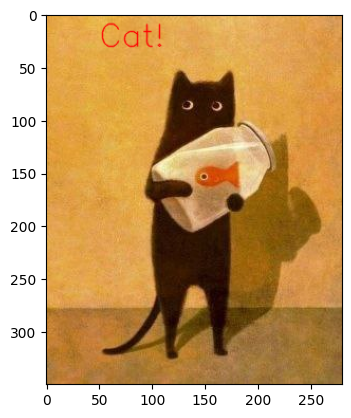

In [67]:
im = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)

cv2.putText(im,"Cat!",(50,30),cv2.FONT_ITALIC,1,(255,0,0),1,cv2.LINE_AA)
plt.imshow(im)

## Events in OpenCV
In OpenCV, events allow us to interact with windows using input devices such as the mouse or keyboard. Examples of events include pressing a key, moving the mouse, or clicking on a window. This makes it possible to create interactive applications like drawing tools, annotation software, or object selection systems.


## Mouse Events
Mouse events are handled using the function:<br>

<code>cv2.setMouseCallback(window_name, callback_function)</code>
- <code>window_name</code>: name of the window where the event will be captured.
- <code>callback_function</code>: a function that is executed whenever a mouse event occurs.

**Common Mouse Events**
Some commonly used event flags are:

- <code>cv2.EVENT_LBUTTONDOWN</code> → Left mouse button pressed
- <code>cv2.EVENT_RBUTTONDOWN</code> → Right mouse button pressed
- <code>cv2.EVENT_MBUTTONDOWN</code> → Middle mouse button pressed
- <code>cv2.EVENT_MOUSEMOVE</code> → Mouse moved
- <code>cv2.EVENT_LBUTTONUP</code> → Left button released


Text(0.5, 1.0, 'Results')

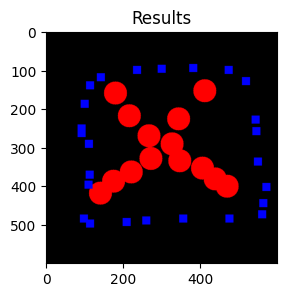

In [14]:
img = np.zeros((600,600,3),np.uint8)

def draw(event,x,y,flags,params):
    if event == cv2.EVENT_LBUTTONDOWN: # Left mouse button pressed
        cv2.circle(img,(x,y),30,(255,0,0),-1)
    elif event == cv2.EVENT_RBUTTONDOWN: # Right mouse button pressed
        cv2.rectangle(img,(x,y),(x+20,y+20),(0,0,255),-1)

cv2.namedWindow('image')
cv2.setMouseCallback('image',draw)


while True:
    cv2.imshow('image',img)
    if cv2.waitKey(1) & 0xFF == 27: # Esc key for closing the window
        break

cv2.destroyAllWindows()

# plot result
plt.figure(figsize=[3,3])
plt.imshow(img);plt.title("Results")

### Brush usuing circles

Text(0.5, 1.0, 'Results')

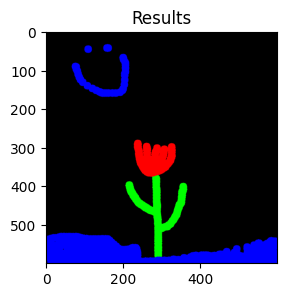

In [19]:
img = np.zeros((600,600,3),np.uint8)

is_drawing = False
color = (255,0,255)
def brush(event,x,y,flag,param):
    global is_drawing,color
    if event == cv2.EVENT_LBUTTONDOWN:
        is_drawing = True
    elif event == cv2.EVENT_MOUSEMOVE:
        if is_drawing:
            cv2.circle(img,(x,y),10,color,-1)
    elif event == cv2.EVENT_LBUTTONUP:
        is_drawing = False

cv2.namedWindow('image')
cv2.setMouseCallback('image',brush)


while True:
    cv2.imshow('image',img)
    key = cv2.waitKey(1) & 0xFF
    if key == 27: # Esc key for closing the window
        break
    elif key == ord('b'):
        color = (255,0,0)
    elif key == ord('g'):
        color = (0,255,0)
    elif key == ord('r'):
        color = (0,0,255)

cv2.destroyAllWindows()

# plot result
plt.figure(figsize=[3,3])
plt.imshow(img[:,:,::-1]);plt.title("Results")

### Brush using lines

Text(0.5, 1.0, 'Results')

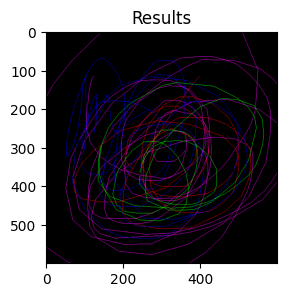

In [ ]:
img = np.zeros((600,600,3),np.uint8)

is_drawing = False
color = (255,0,255)
xi = 0
yi = 0

def brush(event,x,y,flag,param):
    global is_drawing,color,xi,yi
    if event == cv2.EVENT_LBUTTONDOWN:
        is_drawing = True
        xi,yi = x,y
    elif event == cv2.EVENT_MOUSEMOVE:
        if is_drawing:
            cv2.line(img,(xi,yi),(x,y),color,1)
            xi,yi = x,y
    elif event == cv2.EVENT_LBUTTONUP:
        is_drawing = False

cv2.namedWindow('image')
cv2.setMouseCallback('image',brush)


while True:
    cv2.imshow('image',img)
    key = cv2.waitKey(1) & 0xFF
    if key == 27: # Esc key for closing the window
        break
    elif key == ord('b'):
        color = (255,0,0)
    elif key == ord('g'):
        color = (0,255,0)
    elif key == ord('r'):
        color = (0,0,255)

cv2.destroyAllWindows()

# plot result
plt.figure(figsize=[3,3])
plt.imshow(img[:,:,::-1]);plt.title("Results")

## Annotation
Annotation is a fundamental task in computer vision, often used for marking regions of interest (<code>ROIs</code>), bounding boxes, or training datasets. OpenCV provides interactive tools to annotate images using the mouse.

In this example, rectangles are drawn with mouse clicks, and their coordinates are recorded for later use.

[[(105, 47), (187, 107)], [(133, 125), (198, 186)]]


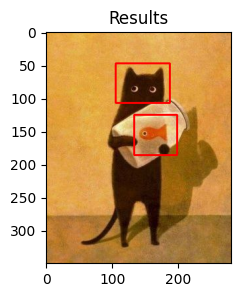

In [24]:
img = cv2.imread("images/Cat.jpg")
reset_img = img.copy()
temp_img = img.copy()

is_drawing = False
start = (0,0)
points = []

def rectangle(event,x,y,flag,param):
    global is_drawing,start,points

    if event == cv2.EVENT_LBUTTONDOWN:
        start = (x,y)
        is_drawing = True
    elif event == cv2.EVENT_MOUSEMOVE:
        if is_drawing:
            temp_img = img.copy()
            cv2.rectangle(temp_img,start,(x,y),(0,0,255),2)
            cv2.imshow('image',temp_img)
    elif event == cv2.EVENT_LBUTTONUP:
        # record end points
        points.append([start,(x,y)])
        # draw
        cv2.rectangle(img,start,(x,y),(0,0,255),2)
        cv2.imshow('image',img)
        is_drawing = False

cv2.namedWindow('image')
cv2.setMouseCallback('image',rectangle)


while True:
    if not is_drawing:
        cv2.imshow('image',img)
    key = cv2.waitKey(1) & 0xFF
    if key == 27: # Esc key for closing the window
        break
    elif key == ord('r'): # Reset
        img = reset_img
        points = []
    elif key == ord('z'): # Undo
        img = reset_img.copy()
        points.pop()
        for p in points:
            cv2.rectangle(img,p[0],p[1],(0,0,255),2)

cv2.destroyAllWindows()

# plot result
plt.figure(figsize=[3,3])
plt.imshow(img[:,:,::-1]);plt.title("Results")
print(points)

## Trackbar
A trackbar is a GUI element (slider) that lets the user change a variable’s value interactively while an OpenCV window is open.

create a trackbar: <code>cv2.createTrackbar(trackbar_name, window_name, min_value, max_value, on_change_callback)</code>

current position of the slider : <code>cv2.getTrackbarPos(trackbar_name, window_name)</code>

Text(0.5, 1.0, 'Results')

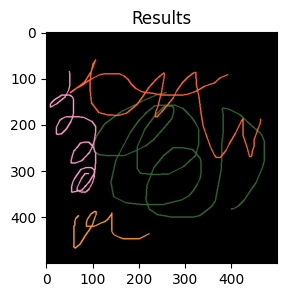

In [8]:
img = np.zeros((500,500,3),np.uint8)
reset_img = img.copy()

thickness = 0
is_drawing = False
color = (0,233,0)
start_point = (0,0)

def nothing(x):
    pass

def brush(event,x,y,flag,param):
    global is_drawing,color,start_point
    if event == cv2.EVENT_LBUTTONDOWN:
        is_drawing = True
        start_point = (x,y)
    elif event == cv2.EVENT_MOUSEMOVE:
        if is_drawing:
            cv2.line(img,start_point,(x,y),color,thickness)
            start_point = (x,y)
    elif event == cv2.EVENT_LBUTTONUP:
        is_drawing = False

cv2.namedWindow('image')

cv2.createTrackbar('Blue','image',0,255,nothing)
cv2.createTrackbar('Green','image',0,255,nothing)
cv2.createTrackbar('Red','image',0,255,nothing)
cv2.createTrackbar('Brush size','image',0,5,nothing)

cv2.setMouseCallback('image',brush)


while True:
    cv2.imshow('image',img)
    key = cv2.waitKey(1) & 0xFF
    if key == 27: # Esc key for closing the window
        break
    elif key == ord('r'): # Reset
        img = reset_img
    B = cv2.getTrackbarPos('Blue','image')
    G = cv2.getTrackbarPos('Green','image')
    R = cv2.getTrackbarPos('Red','image')
    size = cv2.getTrackbarPos('Brush size','image')
    color = (B,G,R)
    thickness = size

cv2.destroyAllWindows()

# plot result
plt.figure(figsize=[3,3])
plt.imshow(img[:,:,::-1]);plt.title("Results")
